In [1]:
from load_data import load_raw_data
from clean_data import clean_data
from split_data import split_data
from evaluate_model import evaluate_model
from config import RANDOM_STATE
from build_pipeline import objective,build_pipeline
from feature_engineering import build_new_features
import optuna
import logging

In [2]:
logging.basicConfig(
    level=logging.INFO,format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

In [3]:
# Loading raw data
dataset=load_raw_data()

2026-08-31 16:29:04,579 | INFO | load_data | Raw dataset loaded.


In [4]:
# Cleaning data
dataset_cleaned=clean_data(dataset)

2026-08-31 16:29:04,590 | INFO | clean_data | Dropped customerID.
2026-08-31 16:29:04,597 | INFO | clean_data | Converted TotalCharges to numeric.
2026-08-31 16:29:04,601 | INFO | clean_data | Rows containing NaN before cleaning: 11
2026-08-31 16:29:04,611 | INFO | clean_data | Removed 11 rows with invalid TotalCharges. Remaining rows with NaN: 0.


In [5]:
# Add new features
#dataset_cleaned=build_new_features(dataset_cleaned)

In [6]:
# Splitting data
X_train, X_test, y_train, y_test=split_data(dataset_cleaned, random_state=RANDOM_STATE)

2026-08-31 16:29:04,625 | INFO | split_data | Data split into train/test set with 0.8/0.2 proportion and random_state=0.


### XGBoost

In [7]:
# Creating optuna study for XGBoost
study_XGB = optuna.create_study(direction="maximize")

[I 2026-08-31 16:29:04,628] A new study created in memory with name: no-name-bd87af00-be53-4433-a690-9672030b7540


In [8]:
# Optimizing optuna study for XGBoost
study_XGB.optimize(lambda trial: objective(trial, X_train, y_train, model='XGBoost'),n_trials=100)

[I 2026-08-31 16:29:06,264] Trial 0 finished with value: 0.6256743209504637 and parameters: {'xgb_n_estimators': 1100, 'xgb_scale_pos_weight': 3.334725528641049, 'xgb_learning_rate': 0.06093800947904231, 'xgb_max_depth': 12, 'xgb_min_child_weight': 10, 'xgb_gamma': 15.153984395005804, 'xgb_subsample': 0.9498976025970167, 'xgb_colsample_bytree': 0.6866081070541482, 'xgb_reg_alpha': 0.017979773810187564, 'xgb_reg_lambda': 0.0029154235597302534}. Best is trial 0 with value: 0.6256743209504637.
[I 2026-08-31 16:29:07,708] Trial 1 finished with value: 0.6125873733246289 and parameters: {'xgb_n_estimators': 500, 'xgb_scale_pos_weight': 4.0891289358294, 'xgb_learning_rate': 0.0073440592383003924, 'xgb_max_depth': 19, 'xgb_min_child_weight': 12, 'xgb_gamma': 18.207146362648388, 'xgb_subsample': 0.6037715291919274, 'xgb_colsample_bytree': 0.8864445723230234, 'xgb_reg_alpha': 0.013307174379224188, 'xgb_reg_lambda': 0.003366551022143122}. Best is trial 0 with value: 0.6256743209504637.
[I 2026-08

In [9]:
print("Best score for XGB:", study_XGB.best_value)
print("Best params for XGB:", study_XGB.best_params)

Best score for XGB: 0.6406277499811683
Best params for XGB: {'xgb_n_estimators': 1000, 'xgb_scale_pos_weight': 2.1872609279591515, 'xgb_learning_rate': 0.006703114235345517, 'xgb_max_depth': 7, 'xgb_min_child_weight': 8, 'xgb_gamma': 19.33164722500418, 'xgb_subsample': 0.354914834602877, 'xgb_colsample_bytree': 0.9996990788814334, 'xgb_reg_alpha': 1.1663319674107813, 'xgb_reg_lambda': 2.1091805829843144}


In [10]:
# Fitting Logistic Regression pipeline with the best trial
pipe_XGB=build_pipeline(trial=study_XGB.best_trial, model= 'XGBoost')
fitted_pipe_XGB=pipe_XGB.fit(X_train, y_train)

### Logistic Regression

In [11]:
# Creating optuna study for Logistic Regression
study_LR = optuna.create_study(direction="maximize")

[I 2026-08-31 16:29:55,834] A new study created in memory with name: no-name-afb6c021-ab38-4a91-ae27-7127034e76cb


In [12]:
# Optimizing optuna study for Logistic Regression
study_LR.optimize(lambda trial: objective(trial, X_train, y_train, model='Logistic Regression'),n_trials=100)

[I 2026-08-31 16:29:55,928] Trial 0 finished with value: 0.6318020795617479 and parameters: {'lr_solver': 'liblinear', 'lr_C': 14.35724628687091, 'lr_penalty': 'l2'}. Best is trial 0 with value: 0.6318020795617479.
[I 2026-08-31 16:29:56,145] Trial 1 finished with value: 0.6312495831904774 and parameters: {'lr_solver': 'sag', 'lr_C': 0.7465923633105102}. Best is trial 0 with value: 0.6318020795617479.
[I 2026-08-31 16:29:56,211] Trial 2 finished with value: 0.6292500327922183 and parameters: {'lr_solver': 'newton-cg', 'lr_C': 0.14758702941512233}. Best is trial 0 with value: 0.6318020795617479.
[I 2026-08-31 16:29:56,287] Trial 3 finished with value: 0.6305880267116067 and parameters: {'lr_solver': 'liblinear', 'lr_C': 3.8483132168828877, 'lr_penalty': 'l2'}. Best is trial 0 with value: 0.6318020795617479.
[I 2026-08-31 16:29:56,353] Trial 4 finished with value: 0.6311479336275791 and parameters: {'lr_solver': 'newton-cg', 'lr_C': 7.313707740452275}. Best is trial 0 with value: 0.63180

In [13]:
print("Best score for LR:", study_LR.best_value)
print("Best params for LR:", study_LR.best_params)

Best score for LR: 0.6324867351893899
Best params for LR: {'lr_solver': 'liblinear', 'lr_C': 19.287553068652826, 'lr_penalty': 'l2'}


In [14]:
# Fitting Logistic Regression pipeline with the best trial
pipe_LR=build_pipeline(trial=study_LR.best_trial, model= 'Logistic Regression')
fitted_pipe_LR=pipe_LR.fit(X_train, y_train)

### K-Nearest Neighbors

In [15]:
# Creating optuna study for K-Nearest Neighbors
study_KNN = optuna.create_study(direction="maximize")

[I 2026-08-31 16:30:10,088] A new study created in memory with name: no-name-3a486353-ee3a-457c-9dde-32737ce88c6b


In [16]:
# Optimizing optuna study for K-Nearest Neighbors
study_KNN.optimize(lambda trial: objective(trial, X_train, y_train, model='K-Nearest Neighbors'),n_trials=100)

[I 2026-08-31 16:30:12,063] Trial 0 finished with value: 0.589824914798456 and parameters: {'knn_n_neighbors': 25, 'k_nn_p': 5}. Best is trial 0 with value: 0.589824914798456.
[I 2026-08-31 16:30:13,969] Trial 1 finished with value: 0.5657811528528357 and parameters: {'knn_n_neighbors': 18, 'k_nn_p': 4}. Best is trial 0 with value: 0.589824914798456.
[I 2026-08-31 16:30:15,811] Trial 2 finished with value: 0.5898108429038871 and parameters: {'knn_n_neighbors': 23, 'k_nn_p': 4}. Best is trial 0 with value: 0.589824914798456.
[I 2026-08-31 16:30:17,659] Trial 3 finished with value: 0.5856987713034165 and parameters: {'knn_n_neighbors': 21, 'k_nn_p': 6}. Best is trial 0 with value: 0.589824914798456.
[I 2026-08-31 16:30:17,756] Trial 4 finished with value: 0.5853538912574139 and parameters: {'knn_n_neighbors': 19, 'k_nn_p': 2}. Best is trial 0 with value: 0.589824914798456.
[I 2026-08-31 16:30:17,945] Trial 5 finished with value: 0.5799861428080755 and parameters: {'knn_n_neighbors': 13, 

In [17]:
print("Best score for KNN:", study_KNN.best_value)
print("Best params for KNN:", study_KNN.best_params)

Best score for KNN: 0.5932583744428449
Best params for KNN: {'knn_n_neighbors': 23, 'k_nn_p': 5}


In [18]:
# Fitting K-Nearest Neighbors pipeline with the best trial
pipe_KNN=build_pipeline(trial=study_KNN.best_trial, model= 'K-Nearest Neighbors')
fitted_pipe_KNN=pipe_KNN.fit(X_train, y_train)

### Support Vector Machine

In [32]:
# Creating optuna study for Support Vector Machine
study_SVM = optuna.create_study(direction="maximize")

[I 2026-08-28 14:07:55,400] A new study created in memory with name: no-name-1012a4ab-7779-4a8d-866b-e82805bcdbf2


In [33]:
# Optimizing optuna study for Support Vector Machine
study_SVM.optimize(lambda trial: objective(trial, X_train, y_train, model='Support Vector Machine'),n_trials=100)

[I 2026-08-28 14:08:00,402] Trial 0 finished with value: 0.6179983160687187 and parameters: {'svc_C': 0.07369898837629608, 'svc_kernel': 'rbf', 'svc_gamma': 0.016802142526929846}. Best is trial 0 with value: 0.6179983160687187.
[I 2026-08-28 14:09:49,535] Trial 1 finished with value: 0.596526081066813 and parameters: {'svc_C': 26.380820802231522, 'svc_kernel': 'linear'}. Best is trial 0 with value: 0.6179983160687187.
[I 2026-08-28 14:09:52,640] Trial 2 finished with value: 0.596526081066813 and parameters: {'svc_C': 0.048118205912096604, 'svc_kernel': 'linear'}. Best is trial 0 with value: 0.6179983160687187.
[I 2026-08-28 14:09:55,716] Trial 3 finished with value: 0.6139766759640791 and parameters: {'svc_C': 0.0011746039260582335, 'svc_kernel': 'linear'}. Best is trial 0 with value: 0.6179983160687187.
[I 2026-08-28 14:09:58,562] Trial 4 finished with value: 0.596526081066813 and parameters: {'svc_C': 0.5978727153804531, 'svc_kernel': 'linear'}. Best is trial 0 with value: 0.61799831

KeyboardInterrupt: 

In [ ]:
print("Best score for SVM:", study_SVM.best_value)
print("Best params for SVM:", study_SVM.best_params)

In [ ]:
# Fitting Support Vector Machine pipeline with the best trial
pipe_SVM=build_pipeline(trial=study_SVM.best_trial, model= 'Support Vector Machine')
fitted_pipe_SVM=pipe_SVM.fit(X_train, y_train)

### Decision Tree

In [19]:
# Creating optuna study for Decision Tree
study_DT = optuna.create_study(direction="maximize")

[I 2026-08-31 16:32:54,139] A new study created in memory with name: no-name-11f8bc89-cda9-4817-99c3-6f3bd5c7fe06


In [20]:
# Optimizing optuna study for Decision Tree
study_DT.optimize(lambda trial: objective(trial, X_train, y_train, model='Decision Tree'),n_trials=100)

[I 2026-08-31 16:32:54,216] Trial 0 finished with value: 0.6110066874492922 and parameters: {'dt_criterion': 'entropy', 'dt_max_depth': 6, 'dt_min_samples_split': 26, 'dt_min_samples_leaf': 10, 'dt_max_features': None}. Best is trial 0 with value: 0.6110066874492922.
[I 2026-08-31 16:32:54,284] Trial 1 finished with value: 0.598189456596962 and parameters: {'dt_criterion': 'gini', 'dt_max_depth': 7, 'dt_min_samples_split': 12, 'dt_min_samples_leaf': 20, 'dt_max_features': 'sqrt'}. Best is trial 0 with value: 0.6110066874492922.
[I 2026-08-31 16:32:54,358] Trial 2 finished with value: 0.5793842833297629 and parameters: {'dt_criterion': 'gini', 'dt_max_depth': 4, 'dt_min_samples_split': 4, 'dt_min_samples_leaf': 18, 'dt_max_features': 'log2'}. Best is trial 0 with value: 0.6110066874492922.
[I 2026-08-31 16:32:54,446] Trial 3 finished with value: 0.593033857251984 and parameters: {'dt_criterion': 'entropy', 'dt_max_depth': 9, 'dt_min_samples_split': 28, 'dt_min_samples_leaf': 13, 'dt_max

In [21]:
print("Best score for DT:", study_DT.best_value)
print("Best params for DT:", study_DT.best_params)

Best score for DT: 0.6142241404458695
Best params for DT: {'dt_criterion': 'gini', 'dt_max_depth': 3, 'dt_min_samples_split': 29, 'dt_min_samples_leaf': 14, 'dt_max_features': None}


In [22]:
# Fitting Decision Tree pipeline with the best trial
pipe_DT=build_pipeline(trial=study_DT.best_trial, model= 'Decision Tree')
fitted_pipe_DT=pipe_DT.fit(X_train, y_train)

### Random Forest

In [23]:
# Creating optuna study for Random Forest
study_RF = optuna.create_study(direction="maximize")

[I 2026-08-31 16:33:00,389] A new study created in memory with name: no-name-c25f18a3-591b-4860-9357-e61f5b0694aa


In [24]:
# Optimizing optuna study for Random Forest
study_RF.optimize(lambda trial: objective(trial, X_train, y_train, model='Random Forest'),n_trials=100)

[I 2026-08-31 16:33:02,832] Trial 0 finished with value: 0.6269106665363124 and parameters: {'rf_n_estimators': 600, 'rf_criterion': 'gini', 'rf_max_depth': 12, 'rf_min_samples_split': 14, 'rf_min_samples_leaf': 3, 'rf_max_features': 'sqrt', 'rf_bootstrap': False}. Best is trial 0 with value: 0.6269106665363124.
[I 2026-08-31 16:33:04,326] Trial 1 finished with value: 0.6351954439420362 and parameters: {'rf_n_estimators': 500, 'rf_criterion': 'entropy', 'rf_max_depth': 14, 'rf_min_samples_split': 25, 'rf_min_samples_leaf': 6, 'rf_max_features': 'sqrt', 'rf_bootstrap': True}. Best is trial 1 with value: 0.6351954439420362.
[I 2026-08-31 16:33:09,428] Trial 2 finished with value: 0.6308875722749562 and parameters: {'rf_n_estimators': 1300, 'rf_criterion': 'entropy', 'rf_max_depth': 15, 'rf_min_samples_split': 25, 'rf_min_samples_leaf': 1, 'rf_max_features': 'sqrt', 'rf_bootstrap': False}. Best is trial 1 with value: 0.6351954439420362.
[I 2026-08-31 16:33:13,951] Trial 3 finished with va

In [25]:
print("Best score for RF:", study_RF.best_value)
print("Best params for RF:", study_RF.best_params)

Best score for RF: 0.6396312425808353
Best params for RF: {'rf_n_estimators': 600, 'rf_criterion': 'entropy', 'rf_max_depth': 10, 'rf_min_samples_split': 21, 'rf_min_samples_leaf': 8, 'rf_max_features': 'log2', 'rf_bootstrap': False}


In [26]:
# Fitting Random Forest pipeline with the best trial
pipe_RF=build_pipeline(trial=study_RF.best_trial, model= 'Random Forest')
fitted_pipe_RF=pipe_RF.fit(X_train, y_train)

### Model performances

2026-08-31 16:39:37,664 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for XGBClassifier classification model.


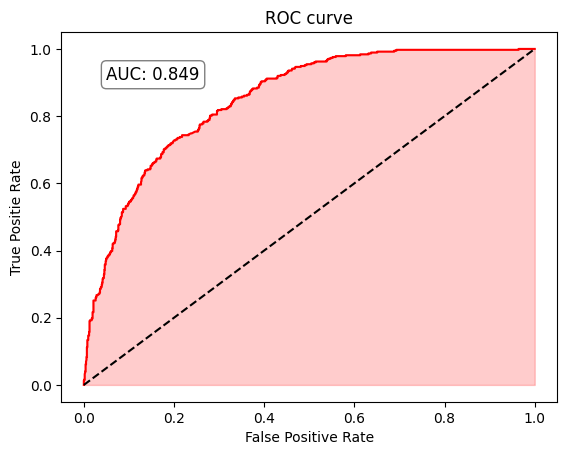

{'classifier_name': 'XGBClassifier',
 'accuracy': 0.771,
 'f1': 0.633,
 'precision': 0.552,
 'recall': 0.743,
 'roc_auc': 0.849,
 'average_precision': 0.658,
 'confusion_matrix': array([[807, 226],
        [ 96, 278]])}

In [27]:
# Evaluate model performance
metrics_XGB,report_XGB=evaluate_model(fitted_pipe_XGB,X_test,y_test)
metrics_XGB

2026-08-31 16:39:37,799 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for LogisticRegression classification model.


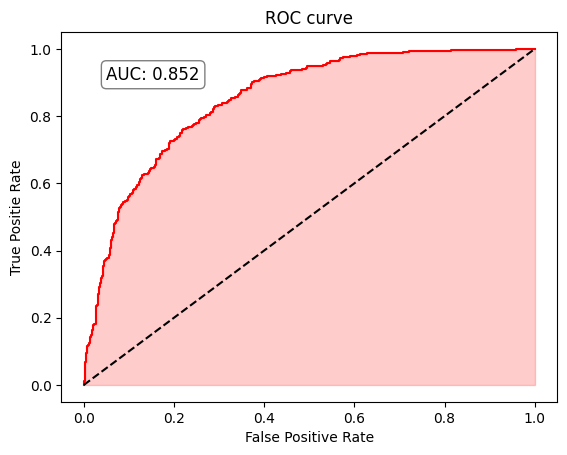

{'classifier_name': 'LogisticRegression',
 'accuracy': 0.753,
 'f1': 0.631,
 'precision': 0.524,
 'recall': 0.794,
 'roc_auc': 0.852,
 'average_precision': 0.658,
 'confusion_matrix': array([[763, 270],
        [ 77, 297]])}

In [28]:
metrics_LR,report_LR=evaluate_model(fitted_pipe_LR,X_test,y_test)
metrics_LR

2026-08-31 16:39:38,928 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for KNeighborsClassifier classification model.


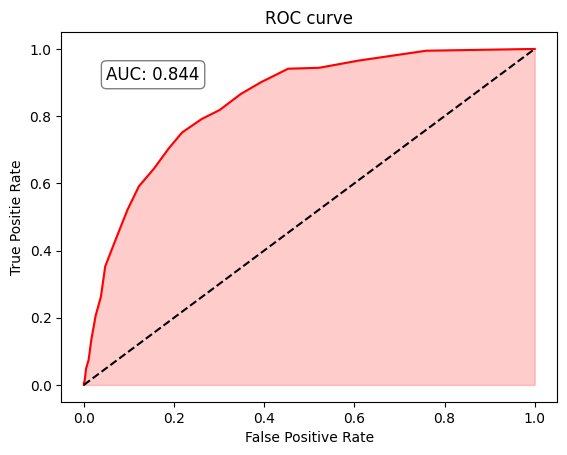

{'classifier_name': 'KNeighborsClassifier',
 'accuracy': 0.802,
 'f1': 0.613,
 'precision': 0.637,
 'recall': 0.591,
 'roc_auc': 0.844,
 'average_precision': 0.622,
 'confusion_matrix': array([[907, 126],
        [153, 221]])}

In [29]:
metrics_KNN,report_KNN=evaluate_model(fitted_pipe_KNN,X_test,y_test)
metrics_KNN

In [ ]:
metrics_SVM,report_SVM=evaluate_model(fitted_pipe_SVM,X_test,y_test)
metrics_SVM

2026-08-31 16:39:39,021 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for DecisionTreeClassifier classification model.


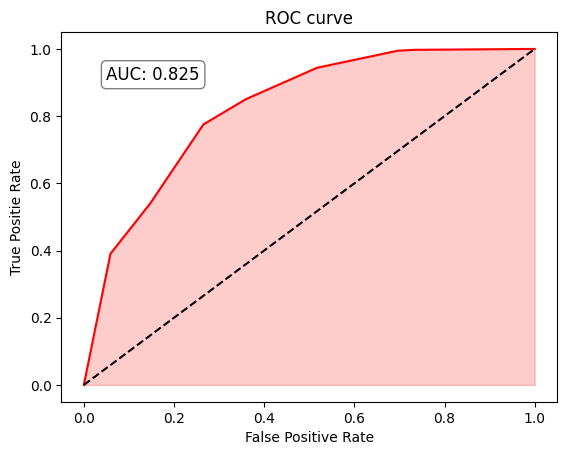

{'classifier_name': 'DecisionTreeClassifier',
 'accuracy': 0.746,
 'f1': 0.618,
 'precision': 0.514,
 'recall': 0.775,
 'roc_auc': 0.825,
 'average_precision': 0.572,
 'confusion_matrix': array([[759, 274],
        [ 84, 290]])}

In [30]:
metrics_DT,report_DT=evaluate_model(fitted_pipe_DT,X_test,y_test)
metrics_DT

2026-08-31 16:39:39,296 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for RandomForestClassifier classification model.


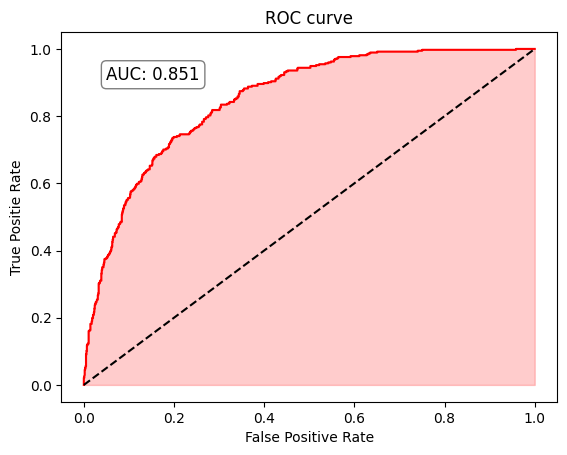

{'classifier_name': 'RandomForestClassifier',
 'accuracy': 0.755,
 'f1': 0.624,
 'precision': 0.527,
 'recall': 0.765,
 'roc_auc': 0.851,
 'average_precision': 0.664,
 'confusion_matrix': array([[776, 257],
        [ 88, 286]])}

In [31]:
metrics_RF,report_RF=evaluate_model(fitted_pipe_RF,X_test,y_test)
metrics_RF